# Splitting videos into a training and a testing set

1. Load annotations from both seasons (2023, 2024)
2. Build a joint data frame containing frame-level annotations
3. Visualize the per-season distribution of every attribute
4. Discard events that contain the single occurence of an attribute in the complete dataset
5. Manually dispatch events containing rare attributes in either the training or the testing set
6. Perform data split at the day level, such that events from the same days are part of the same split. We aim for a train-test ratio of 4:1
7. Visualize attribute distribution per split. We ensure that for every attribute, the proportion of video files in the train set is comprised between 50% and 90% 
8. Visualize the distribution of days per split


In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import calendar
import sqlite3

from md_output_parser import MDVideoOutputParser
from events_train_test_split import random_day_split 

%load_ext autoreload
%autoreload 2

In [2]:
# Figure aesthetics
mpl_config = {
    "figure.figsize": (12, 8),
    "figure.dpi": 100,
    "figure.facecolor": "white",

    # Font settings
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "font.size": 15,

    # Title and Label size
    "axes.titlesize": 20,
    "axes.labelsize": 15,

    # Tick parameters
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    # Grid and Spines for readability
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.edgecolor": "black",
    "axes.linewidth": 1,

    # Legend
    "legend.fontsize": 12,
    "legend.frameon": True,
    "legend.loc": "best",
}

plt.rcParams.update(mpl_config)

# Steps 1 - 3: Building the joint dataset

### 2024

In [9]:
# Load frame-level annotations in JSON format
annotated_tracklets_folder = Path("/media/EVO870/datasets/SNP_Summer_2024/experiments/Data_Processing_2024/annotated_tracklets_json")
database_path = Path("/media/EVO870/datasets/SNP_Summer_2024/database.db")

md_parser = MDVideoOutputParser()
annotated_tracklets_dict = md_parser.parse_folder(annotated_tracklets_folder)
annotated_tracklets_df = md_parser.to_dataframe()

annotated_tracklets_df.sample(2)

  0%|          | 0/1069 [00:00<?, ?it/s]

100%|██████████| 1069/1069 [00:07<00:00, 145.68it/s]


,frame_id,detections,file_id,detection_file_path,max_detection_conf,conf,category,track_id,bbox,outside,is_annotated,occluded,segment_id,attributes.Action,attributes.Action2,attributes.Activity,attributes.Social_activity_role,attributes.Deer_adult_sex,attributes.Deer_age,attributes.Species
507627,1423,"{'conf': 1.0, 'track_id': 2, 'bbox': [0.914464...",S1_C2_E278_V0430,S1/C2/S1_C2_E278_V0430.json,1.0,1.0,1.0,2.0,"[0.9144642857142857, 0.2426984126984127, 0.062...",False,True,True,1.0,walking,none,foraging,n/a,NaN,juvenile,red_deer
175874,113,NaN,S1_C3_E268_V0180,S1/C3/S1_C3_E268_V0180.json,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Add metadata about datetime, event id and tublet duration
conn = sqlite3.connect(database_path)
videos_metadata_df = pd.read_sql("SELECT * FROM Videos", con=conn)
tracklets_metadata_df = pd.read_sql("SELECT * FROM Tracklets", con=conn)
conn.close()

annotated_tracklets_df = (
    annotated_tracklets_df[
        ["file_id", "track_id", "segment_id", "frame_id", "is_annotated", "attributes.Action", "attributes.Action2", "attributes.Activity", "attributes.Deer_adult_sex", "attributes.Deer_age", "attributes.Species"]]
    .merge(videos_metadata_df[["file_id", "event_id", "date_time", "site_cam_id"]], on="file_id")
    .merge(tracklets_metadata_df[["tublet_file_id", "file_id", "track_id", "segment_id", "tublet_duration"]], on=["file_id", "track_id", "segment_id"])
)

# Additional formatting
# Set 2nd action to NaN if "none"
none_action2_idx = annotated_tracklets_df[annotated_tracklets_df["attributes.Action2"] == "none"].index
annotated_tracklets_df.loc[none_action2_idx, "attributes.Action2"] = np.nan

# set other_small_mammal label name to marten
marten_idx = annotated_tracklets_df[annotated_tracklets_df["attributes.Species"] == "other_small_mammal"].index
annotated_tracklets_df.loc[marten_idx, "attributes.Species"] = "marten"

# Lower column names
annotated_tracklets_df.columns = [c.lower() for c in annotated_tracklets_df.columns]

annotated_tracklets_df.sample(2)

,file_id,track_id,segment_id,frame_id,is_annotated,attributes.action,attributes.action2,attributes.activity,attributes.deer_adult_sex,attributes.deer_age,attributes.species,event_id,date_time,site_cam_id,tublet_file_id,tublet_duration
591854,S2_C2_E489_V0046,2.0,1.0,190,False,NaN,NaN,NaN,NaN,NaN,NaN,E489,2024-07-03 03:33:16,S2_C2,S2_C2_E489_V0046_ID2_T1,11.866667
499574,S2_C3_E625_V0155,3.0,1.0,1404,True,browsing,NaN,foraging,NaN,juvenile,red_deer,E625,2024-08-21 07:38:22,S2_C3,S2_C3_E625_V0155_ID3_T1,78.333333


In [11]:
annotated_tracklets_2024_df = annotated_tracklets_df.copy()

### 2023

In [12]:
# Load frame-level annotations in JSON format
annotated_tracklets_folder = Path("/media/MX500/valentin/datasets/SNP_Summer_2023/SNP_Summer_2023_annotated_tracks_v5")
database_path = Path("/media/MX500/valentin/datasets/SNP_Summer_2023/annotation/raw_videos_metadata.csv")
tracklets_metadata_path = Path("/media/MX500/valentin/datasets/SNP_Summer_2023/annotation/tublets_v5.csv")

md_parser = MDVideoOutputParser()
annotated_tracklets_dict = md_parser.parse_folder(annotated_tracklets_folder)

annotated_tracklets_df = md_parser.to_dataframe()
annotated_tracklets_df.sample(2)

  0%|          | 0/1746 [00:00<?, ?it/s]

100%|██████████| 1746/1746 [00:11<00:00, 149.42it/s]


,frame_id,max_detection_conf,detections,width,height,file_id,detection_file_path,conf,category,track_id,...,occluded,segment_id,attributes.Activity,attributes.Action2,attributes.Social_activity_role,attributes.Action,attributes.Species,attributes.Deer_adult_sex,attributes.Deer_age,outside
739267,396,0.959,"{'conf': 0.9589999914169312, 'category': 1, 't...",1920,1080,S3_C2_E617_V0132,S3/C2/S3_C2_E617_V0132.json,0.959,1.0,1.0,...,False,1.0,camera_reaction,looking_at_camera,n/a,standing_head_up,red_deer,female,adult,NaN
766148,831,1.000,"{'conf': 1.0, 'track_id': 1, 'bbox': [0.563541...",1920,1080,S3_C2_E642_V0146,S3/C2/S3_C2_E642_V0146.json,1.000,1.0,1.0,...,False,1.0,foraging,none,n/a,standing_head_down,red_deer,NaN,juvenile,False


In [13]:
# Add metadata about datetime, event id and tublet duration
videos_metadata_df = pd.read_csv(database_path)
tracklets_metadata_df = pd.read_csv(tracklets_metadata_path, index_col=0)

annotated_tracklets_df = (
    annotated_tracklets_df[
        ["file_id", "track_id", "segment_id", "frame_id", "attributes.Action", "attributes.Action2", "attributes.Activity", "attributes.Deer_age", "attributes.Deer_adult_sex", "attributes.Species"]]
    .merge(videos_metadata_df[["file_id", "event_id", "date_time", "site_id", "cam_id"]], on="file_id")
    .merge(tracklets_metadata_df[["tublet_file_id", "file_id", "track_id", "segment_id", "tublet_duration"]], on=["file_id", "track_id", "segment_id"])
)


# Additional formatting
# Set 2nd action to NaN if "none"
none_action2_idx = annotated_tracklets_df[annotated_tracklets_df["attributes.Action2"] == "none"].index
annotated_tracklets_df.loc[none_action2_idx, "attributes.Action2"] = np.nan

# set other_small_mammal label name to marten
marten_idx = annotated_tracklets_df[annotated_tracklets_df["attributes.Species"] == "other_small_mammal"].index
annotated_tracklets_df.loc[marten_idx, "attributes.Species"] = "marten"

# Lower column names
annotated_tracklets_df.columns = [c.lower() for c in annotated_tracklets_df.columns]

# Rename some attributes to match 2024
annotated_tracklets_df = annotated_tracklets_df.rename(columns={"attributes.red_deer_age_group": "attributes.deer_age","attributes.red_deer_adult_sex":"attributes.deer_adult_sex"})
annotated_tracklets_df["attributes.deer_age"] = annotated_tracklets_df["attributes.deer_age"].str.replace("young", "juvenile")
annotated_tracklets_df["attributes.action"] = annotated_tracklets_df["attributes.action"].str.replace("none", "unknown")
annotated_tracklets_df["attributes.activity"] = annotated_tracklets_df["attributes.activity"].str.replace("none", "unknown")

annotated_tracklets_df.sample(2)

,file_id,track_id,segment_id,frame_id,attributes.action,attributes.action2,attributes.activity,attributes.deer_age,attributes.deer_adult_sex,attributes.species,event_id,date_time,site_id,cam_id,tublet_file_id,tublet_duration
804599,S3_C2_E722_V0280,1.0,1.0,810,standing_head_up,NaN,vigilance,adult,male,red_deer,E722,2023-09-22 16:48:32,S3,C2,S3_C2_E722_V0280_ID1_T1,47.833333
753788,S3_C2_E792_V0522,2.0,1.0,788,laying_down,bathing,resting,adult,male,red_deer,E792,2023-10-01 13:32:00,S3,C2,S3_C2_E792_V0522_ID2_T1,60.500000


In [15]:
annotated_tracklets_2023_df = annotated_tracklets_df.copy()

### Joining 2024 and 2023

In [16]:
# We rename event_ids of 2024 from EXXX to FXXX, and proceed accordingly for file ids
annotated_tracklets_2024_df["event_id"] = annotated_tracklets_2024_df["event_id"].str.replace("E", "F")
annotated_tracklets_2024_df["file_id"] = annotated_tracklets_2024_df["file_id"].str.replace("E", "F")

# We add a "year" column
annotated_tracklets_2024_df["year"] = 2024
annotated_tracklets_2023_df["year"] = 2023

total_df = pd.concat([annotated_tracklets_2023_df, annotated_tracklets_2024_df], axis=0)

### Visualizing attributes distribution

In [ ]:
def get_attribute_df(annotated_tracklets_df: pd.DataFrame, col_name: str):
    if isinstance(col_name, list):
        df = pd.concat([
            annotated_tracklets_df
            .groupby(col)
            .agg({"event_id": pd.Series.nunique, "year": "min"})
            for col in col_name], axis=0)
        attributes_df = df.groupby(level=0).agg({"event_id": "sum", "year": "min"}).sort_values("event_id", ascending=False)
    else:
        attributes_df = (
            annotated_tracklets_df
            .groupby(col_name)
            .agg({"event_id": pd.Series.nunique, "year": "min"})
            .sort_values("event_id", ascending=False)
        )

    attributes_df["perc"] = attributes_df["event_id"] * 100 / attributes_df["event_id"].sum()

    return attributes_df

def plot_multi_season_frequencies(total_df: pd.DataFrame, col_name, log=False):

    df_2023 = total_df[total_df["year"] == 2023]
    df_2024 = total_df[total_df["year"] == 2024]

    total_df = pd.concat([get_attribute_df(df_2023, col_name), get_attribute_df(df_2024, col_name)], axis=0)
    if isinstance(col_name, list):
        total_df = total_df.reset_index(names=col_name[0]).groupby([col_name[0], "year"]).sum().unstack().fillna(0)
    else:
        total_df = total_df.reset_index().groupby([col_name, "year"]).sum().unstack().fillna(0)
    total_df["total"] = total_df[("event_id", 2023)] + total_df[("event_id", 2024)]
    total_df = total_df.sort_values("total", ascending=False)
    total_df["perc"] = total_df["total"] * 100 / total_df["total"].sum()

    fig, ax = plt.subplots(1,1, figsize=(12,8))
    cmap_full = plt.get_cmap("GnBu")
    colors = [cmap_full(i) for i in np.linspace(0.25, 0.8, 2)]
    custom_cmap = ListedColormap(colors)

    total_df[["event_id"]].plot(kind="bar", width=0.8, edgecolor="k", ax=ax, stacked=True, cmap=custom_cmap, logy=log)

    ax.set_xticklabels(total_df.index.to_list(), rotation=30, ha="right")
    plt.grid(axis="y")
        
    # Add percentage text on each bar
    for i, (idx, row) in enumerate(total_df[["total", "perc"]].iterrows()):
        bar = ax.patches[i]
        height = row["total"].values[0] + 2
        perc = "<1" if row["perc"].values[0] < 1.0 else f'{row["perc"].values[0]:.1f}'
        color = "red" if row["total"].values[0] <= 5 else "black"
        ax.text(
            bar.get_x() + bar.get_width()/2, 
            height, 
            f'{row["total"].values[0]:.0f}\n({perc})%', 
            ha='center', 
            va='bottom', 
            fontsize=11, 
            color=color
        )

    ax.set_ylim(0.9, total_df["total"].max() + 40)
    plt.legend(["2023", "2024"])
    
    plt.show()

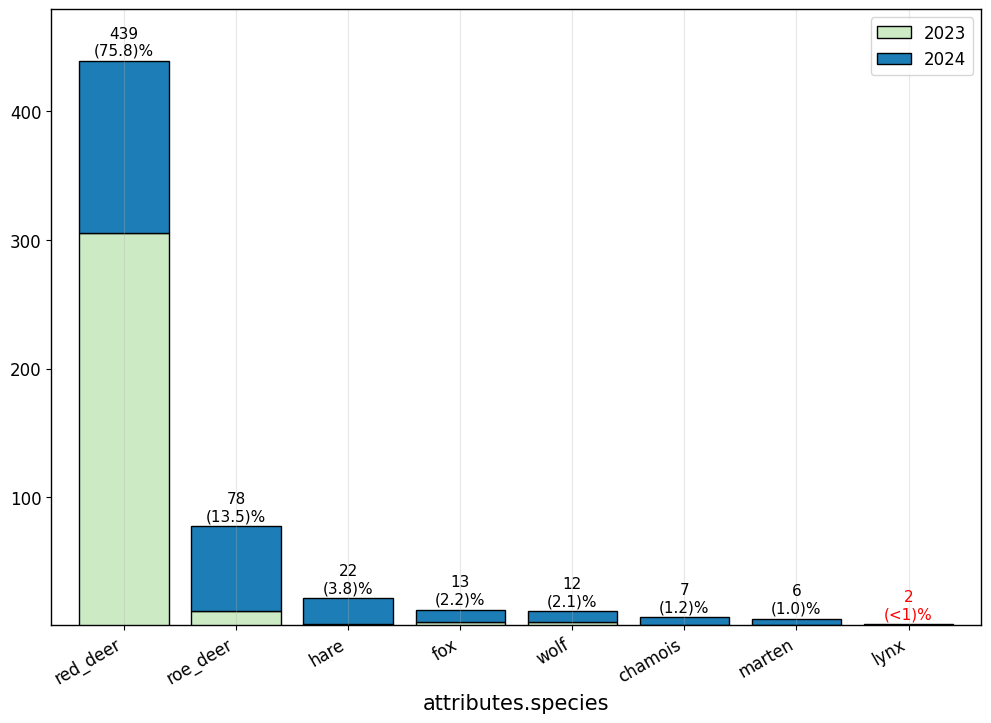

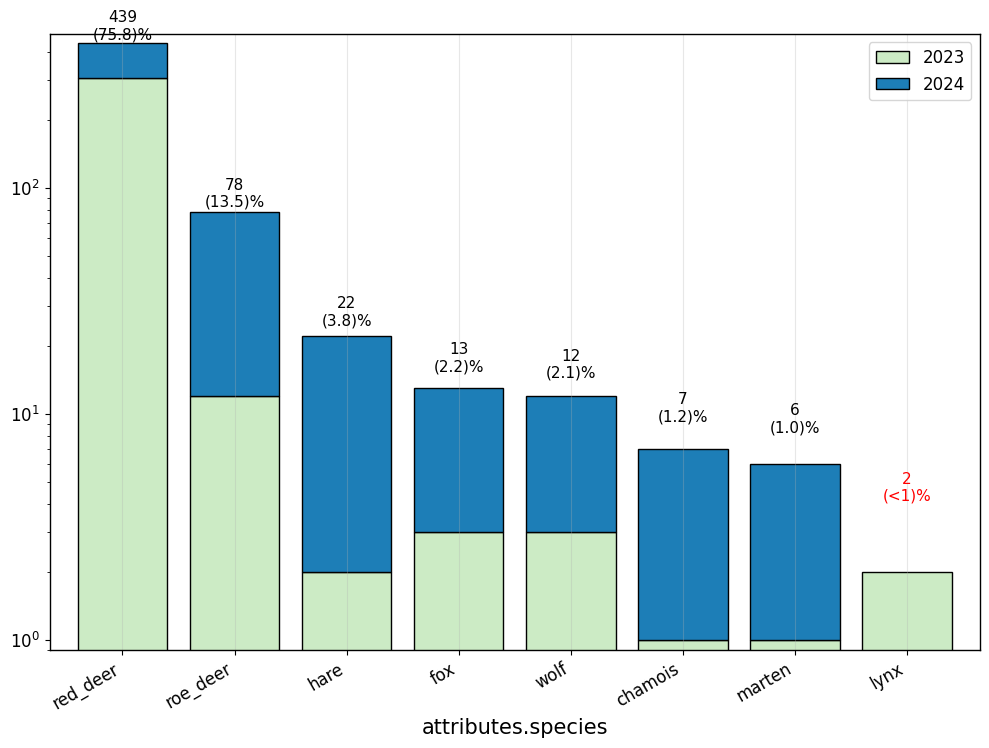

In [32]:
plot_multi_season_frequencies(total_df, "attributes.species")
plot_multi_season_frequencies(total_df, "attributes.species", log=True)

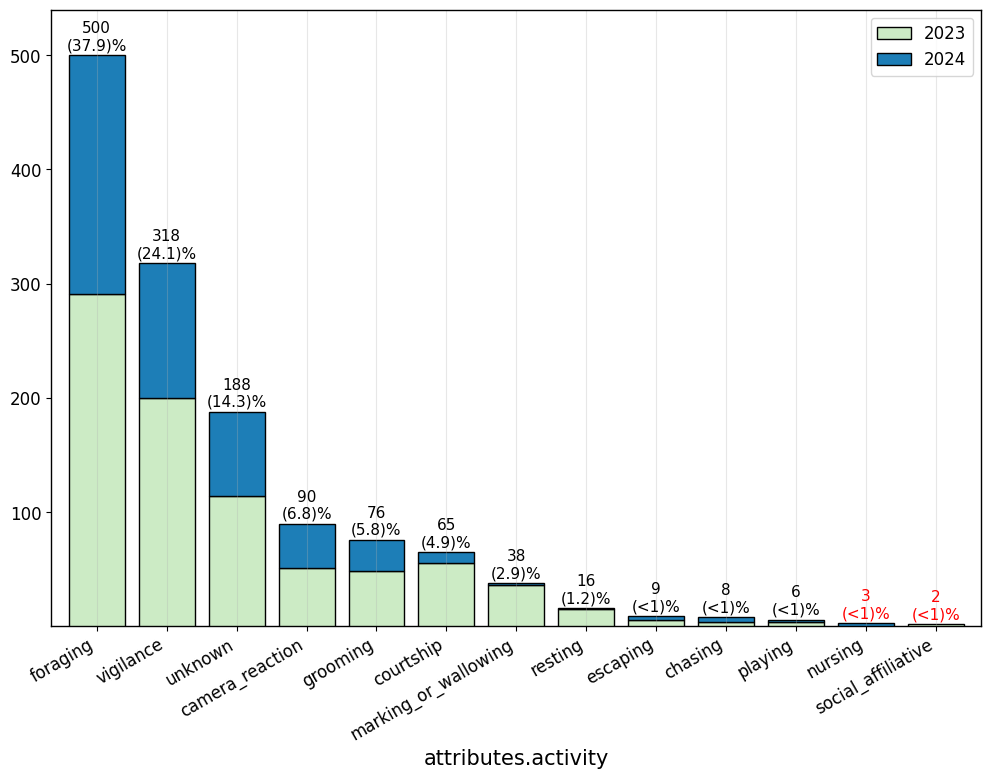

In [33]:
plot_multi_season_frequencies(total_df, "attributes.activity")

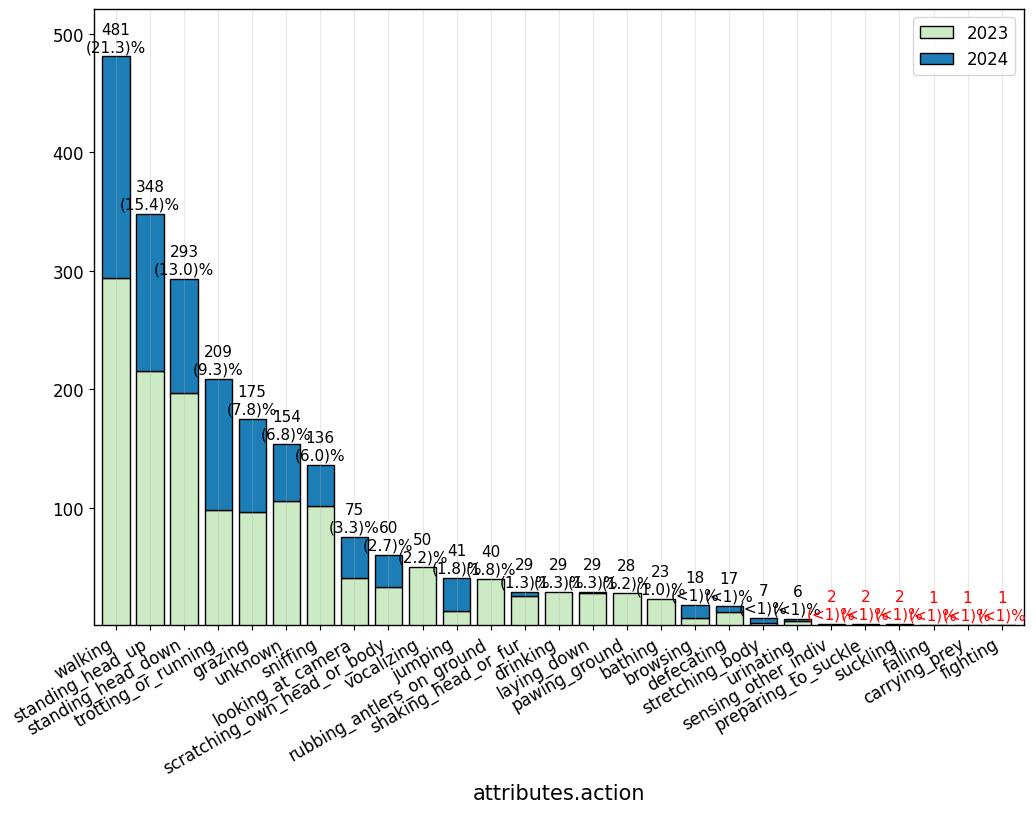

In [34]:
plot_multi_season_frequencies(total_df, ["attributes.action", "attributes.action2"])

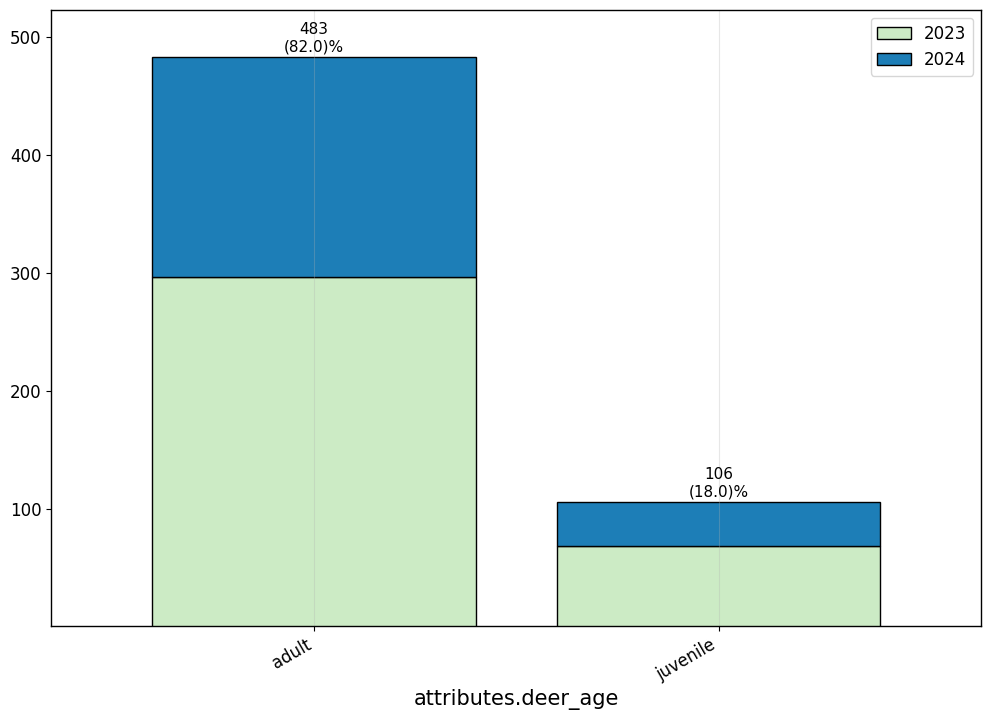

In [35]:
plot_multi_season_frequencies(total_df, "attributes.deer_age")

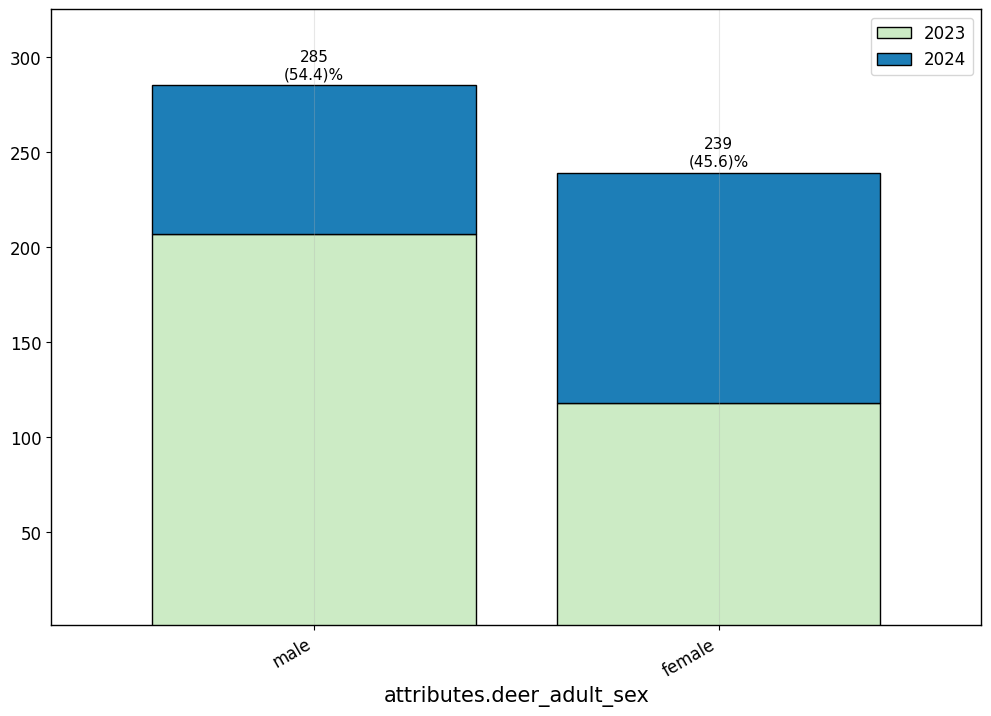

In [36]:
plot_multi_season_frequencies(total_df, "attributes.deer_adult_sex")

# Steps 4 - 8: Making data split and visualizing distributions

In [37]:
DISCARD = [
    "E56",   # Fighting / Social affiliative
    "E99",   # Social affiliative
    "E186",  # Lynx
    "E187",  # Lynx
    "F460",  # Falling
    "F682"   # Carrying_prey
]

MANDATORY_TRAIN= [
    "E51",  # Hare
    "E86",  # Chasing / Escaping
    "E280", # Jumping / Browsing
    "E324", # Fox
    "E327", # Fox
    "E389", # Wolf
    "E394", # Wolf
    "E642", # Chasing / Escaping
    "E693", # Playing / Escaping
    "E766", # Bathing
    "E769", # Bathing
    "F23",  # Chamois
    "F55",  # Chamois
    "F65",  # Chamois
    "F75",  # Playing
    "F230", # Chamoi
    "F243", # Streching / Suckling
    "F253", # To add files in train set
    "F386", # Chasing
    "F594", # Fox / Urinating
    "F474", # Marten
    "F475", # Marten
    "F548", # Marten
    "F700", # Defecating
    "F746", # Defecating
    "F737", # Defecating
]

MANDATORY_TEST = [
    "E61",  # Hare
    "E118", # Defecating
    "E292", # Wolf
    "E385", # Fox
    "E545", # Bathing
    "E638", # Urinating
    "E671", # Defecating
    "E704", # Defecating
    "E710", # Playing
    "F163", # Escaping
    "F168", # Chamois
    "F169", # Chamois
    "F269", # To add more juveniles in test set
    "F288", # Event overlapping on 2 days, incl. a test day
    "F404", # Suckling
    "F491", # Marten
    "F498", # Marten
    "F568", # Playing
    "F573", # Wolf / Escaping
    "F464", # Fox / Urinating
    "F720", # Browsing / Defecating
    "F863", # Browsing / Defecating
    "F874", # Chasing
]

In [38]:
total_df["split"] = ""

# Checking for potentially overlapping days
split_df = total_df[~total_df["event_id"].isin(DISCARD)].copy().reset_index(drop=True)
split_df["date_time"] = pd.to_datetime(split_df["date_time"])

train_idx = split_df[split_df["event_id"].isin(MANDATORY_TRAIN)].index
test_idx = split_df[split_df["event_id"].isin(MANDATORY_TEST)].index

split_df.loc[train_idx, "split"] = "train"
split_df.loc[test_idx, "split"] = "test"

train_days = split_df[split_df["split"]=="train"]["date_time"].dt.date.sort_values().unique()
test_days = split_df[split_df["split"]=="test"]["date_time"].dt.date.sort_values().unique()

print("Overlapping days:", set(train_days).intersection(set(test_days)))

Overlapping days: set()


In [47]:
# Perform split
train_events, val_events, test_events = random_day_split(
    annotations_df=split_df,
    train_size=0.75,
    test_size=0.25,
    train_init = MANDATORY_TRAIN, 
    test_init=MANDATORY_TEST, 
    seed=0, 
    n_iter=50,
    no_val=True
)

Search parameters:
	 Target train size: 0.75 - Target val size: 0 - Target test size: 0.25
	 Init train set prop: 0.311
	 Init test set prop: 0.247
	 Number of iterations: 50


100%|██████████| 50/50 [00:55<00:00,  1.11s/it]

Train prop: 0.7490794746657483
Val prop: 0.0
Test prop: 0.2509205253342517


In [48]:
split_df.loc[split_df[split_df["event_id"].isin(train_events)].index, "split"] = "train"
split_df.loc[split_df[split_df["event_id"].isin(test_events)].index, "split"] = "test"
print("Entries not assigned to a split:", len(split_df[~split_df["split"].isin(["train", "test"])]))

Entries not assigned to a split: 0


In [49]:
def plot_split_frequencies(df: pd.DataFrame, col_name: str, log=False):

    fig, ax = plt.subplots(1,1, figsize=(12,8))

    # First get total number of events
    if isinstance(col_name, list):
        attributes_df = pd.concat([
            df
            .groupby([col, "split"], as_index=True)
            .agg({"file_id": pd.Series.nunique})
            for col in col_name], axis=0)
        attributes_df = attributes_df.reset_index(names=["attributes", "split"]).groupby(["attributes", "split"]).sum().sort_values("file_id", ascending=False)
    else:
        attributes_df = (
            df
            .groupby([col_name, "split"])
            .agg({"file_id": pd.Series.nunique})
            .sort_values("file_id", ascending=False)
        )
    
    attributes_df = attributes_df.rename(columns={"file_id": "nb_files"})
    total_df = attributes_df.unstack().fillna(0)
    total_df["total"] = total_df[("nb_files", "train")] + total_df[("nb_files", "test")]
    total_df = total_df.sort_values("total", ascending=False)
    total_df["train_split_perc"] = total_df[("nb_files", "train")] * 100 / total_df["total"]
    total_df = total_df.sort_index(level=1, axis=1, ascending=False)

    cmap_full = plt.get_cmap("OrRd")
    colors = [cmap_full(i) for i in np.linspace(0.25, 0.8, 2)]
    custom_cmap = ListedColormap(colors)

    total_df[["nb_files"]].plot(kind="bar", width=0.8, edgecolor="k", ax=ax, stacked=True, cmap=custom_cmap, logy=log)
    
    ax.set_xticklabels(total_df.index.to_list(), rotation=30, ha="right")
    plt.grid(axis="y")
        
    # Add percentage text on each bar
    for i, (idx, row) in enumerate(total_df[["total", "train_split_perc"]].iterrows()):
        bar = ax.patches[i]
        height = row["total"].values[0] + 2
        perc = f'{row["train_split_perc"].values[0]:.1f}'
        color = "black"
        ax.text(
            bar.get_x() + bar.get_width()/2, 
            height, 
            f'{perc}%', 
            ha='center', 
            va='bottom', 
            fontsize=9, 
            color=color
        )

    ax.set_ylim(0.9, total_df["total"].max() + 40)
    plt.legend(["train", "test"])
    
    plt.show()

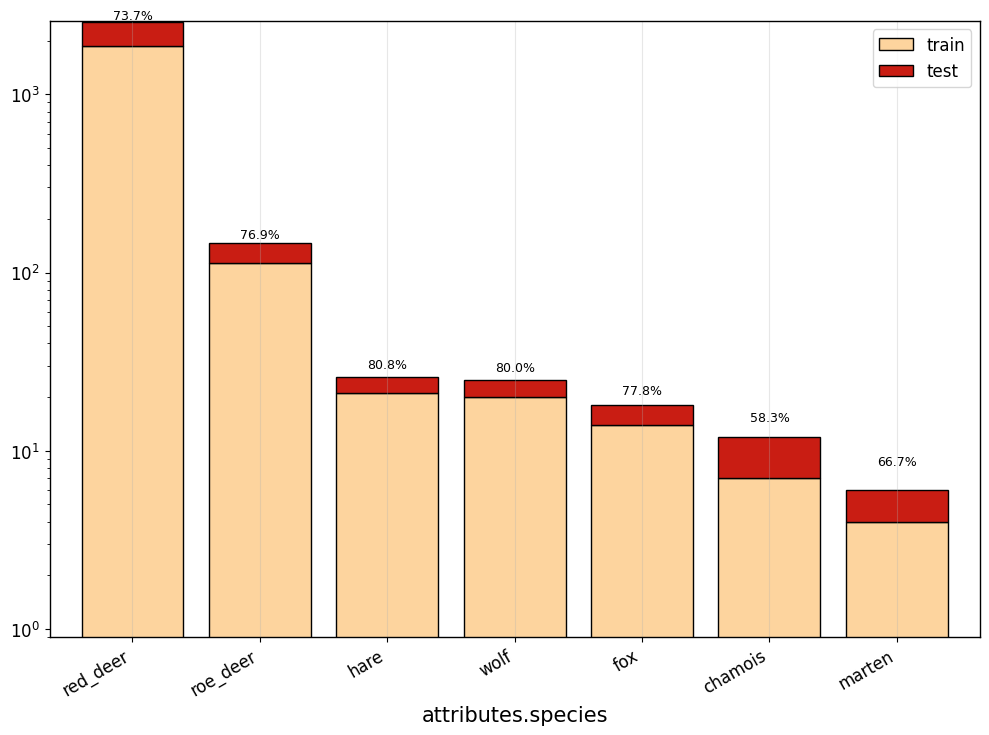

In [50]:
plot_split_frequencies(split_df, "attributes.species", log=True)

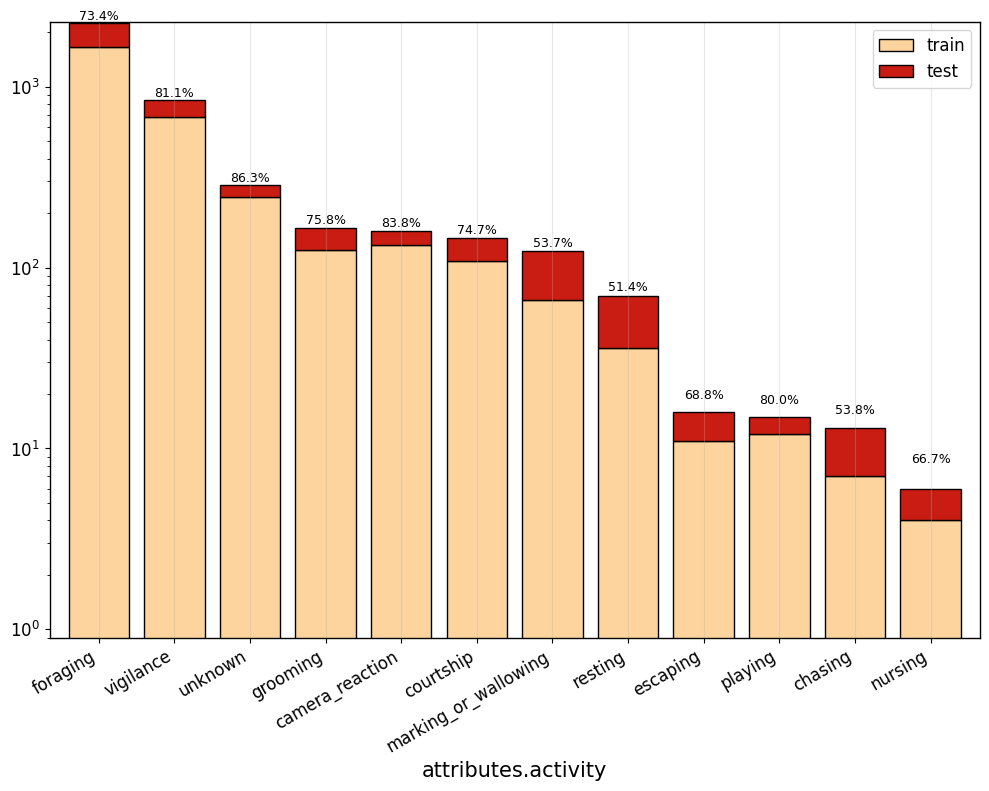

In [51]:
plot_split_frequencies(split_df, "attributes.activity", log=True)

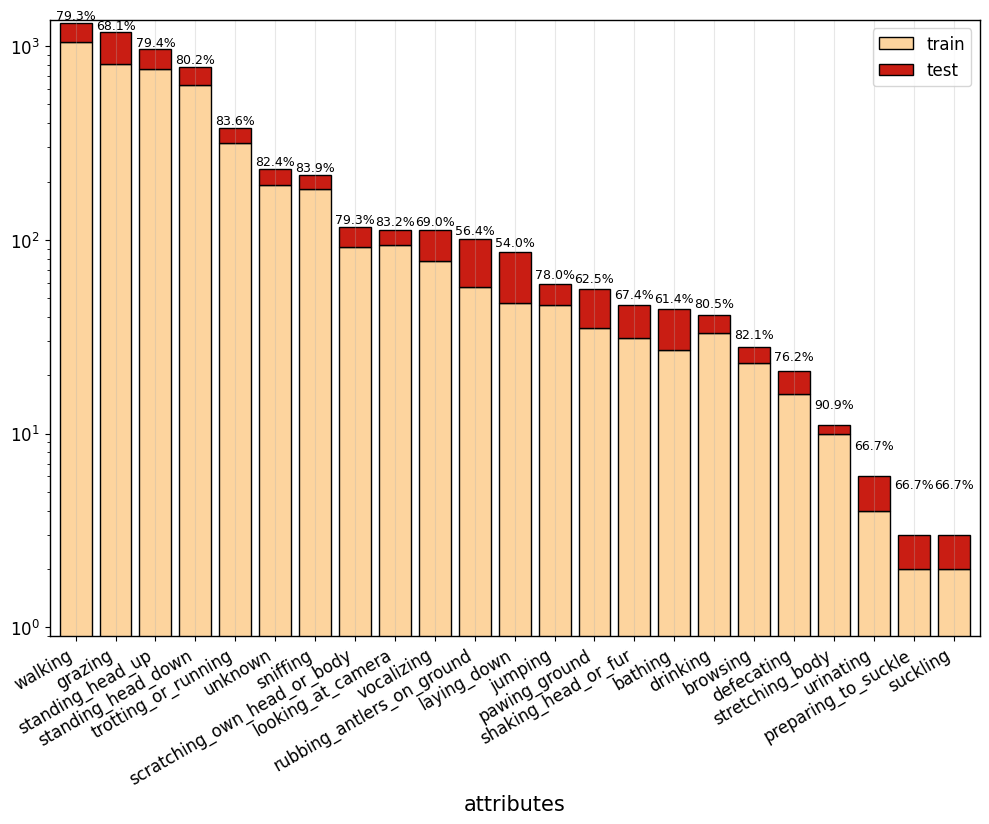

In [52]:
plot_split_frequencies(split_df, ["attributes.action", "attributes.action2"], log=True)

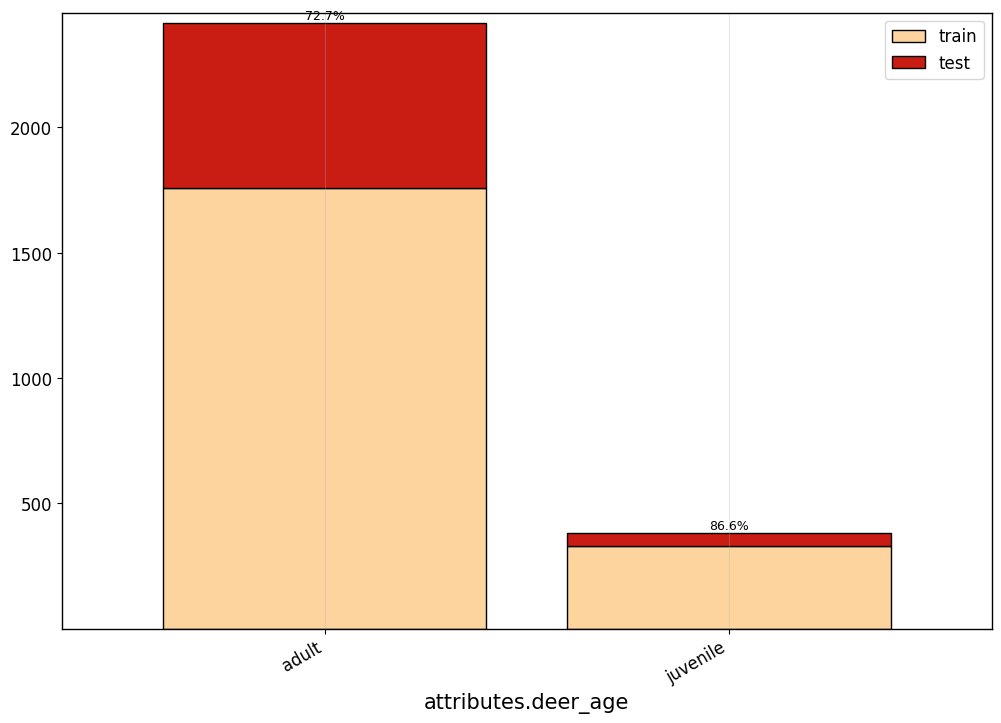

In [53]:
plot_split_frequencies(split_df, "attributes.deer_age")

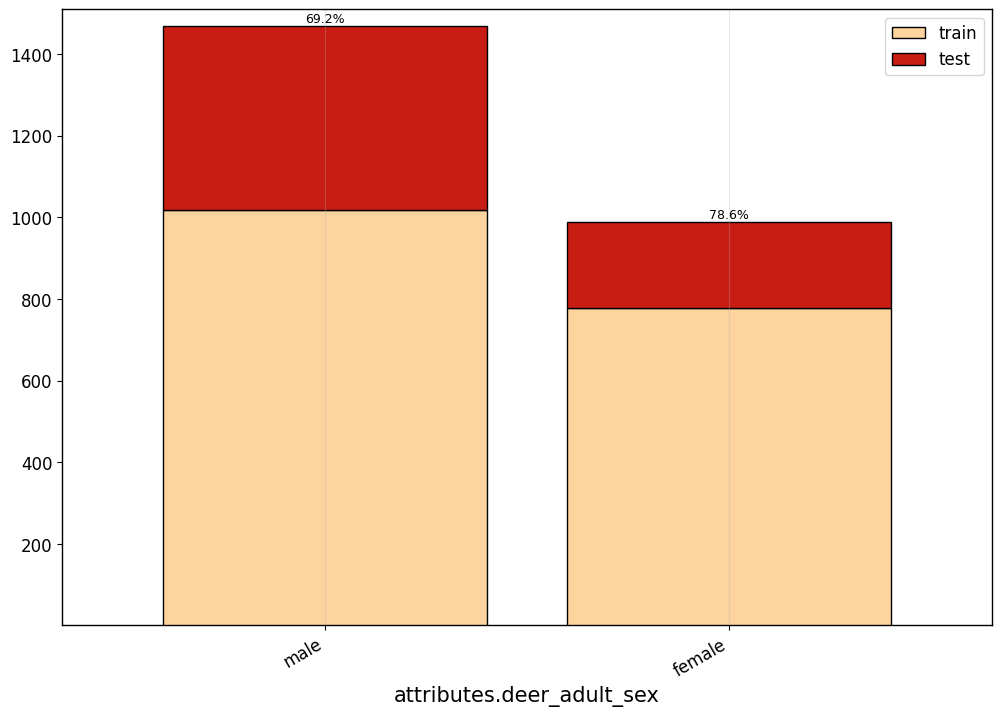

In [54]:
plot_split_frequencies(split_df, "attributes.deer_adult_sex")

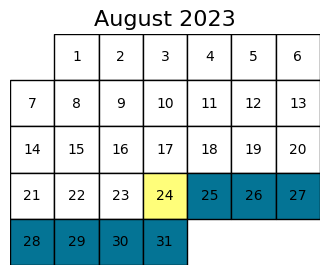

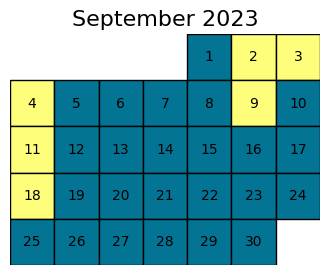

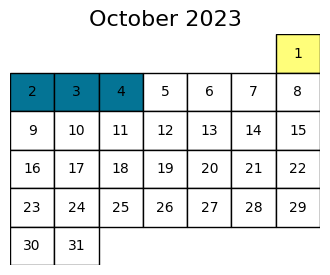

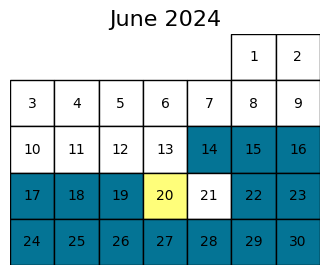

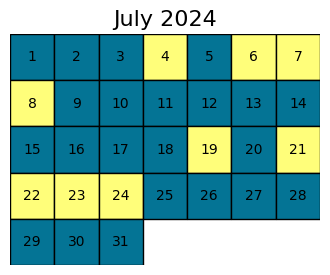

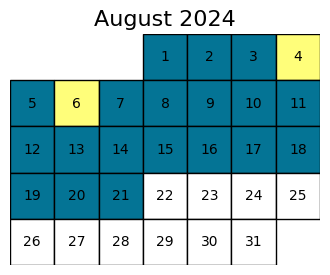

In [62]:
train_days = split_df[split_df["split"]=="train"]["date_time"].dt.date.unique()
test_days = split_df[split_df["split"]=="test"]["date_time"].dt.date.unique()

def plot_calendar(train_days, test_days):
    # Combine all days and determine the range of years and months
    all_days = list(train_days) + list(test_days)
    min_year, max_year = min(day.year for day in all_days), max(day.year for day in all_days)
    min_month, max_month = min(day.month for day in all_days), max(day.month for day in all_days)

    # Iterate over each year and month in the range
    for year in range(min_year, max_year + 1):
        for month in range(1, 13):  # Iterate through all months
            # Filter days for the current year and month
            train_days_month = [day for day in train_days if day.year == year and day.month == month]
            test_days_month = [day for day in test_days if day.year == year and day.month == month]

            # Skip months with no data
            if not train_days_month and not test_days_month:
                continue

            # Create a matrix for the calendar
            cal = calendar.Calendar(firstweekday=0)  # Start with Monday
            month_days = cal.monthdayscalendar(year, month)

            # Create a color map for the days
            day_colors = {}
            for day in train_days_month:
                day_colors[day.day] = "xkcd:sea blue"
            for day in test_days_month:
                day_colors[day.day] = "xkcd:light yellow"

            # Plot the calendar
            fig, ax = plt.subplots(figsize=(4, 3))
            ax.set_xlim(0, 7)
            ax.set_ylim(0, len(month_days))
            ax.axis("off")

            # Add days and color them
            for week_idx, week in enumerate(month_days):
                for day_idx, day in enumerate(week):
                    if day != 0:  # Skip padding days
                        color = day_colors.get(day, "white")  # Default to white if not in train/test
                        ax.add_patch(plt.Rectangle((day_idx, len(month_days) - week_idx - 1), 1, 1, color=color, ec="black"))
                        ax.text(day_idx + 0.5, len(month_days) - week_idx - 1 + 0.5, str(day), ha="center", va="center", fontsize=10)

            plt.title(f"{calendar.month_name[month]} {year}", fontsize=16)
            plt.show()

plot_calendar(train_days, test_days)


In [64]:
videos_split_dict = {
    "train_file_ids": sorted(list(split_df[split_df["split"] == "train"]["file_id"].unique())),
    "test_file_ids": sorted(list(split_df[split_df["split"] == "test"]["file_id"].unique()))
}

In [63]:
split_df["behavior"] = split_df.fillna("").apply(lambda d: " ".join([d["attributes.activity"], d["attributes.action"], d["attributes.action2"]]), axis=1)
split_df["behavior"] = split_df["behavior"].str.strip()
print(len(split_df["behavior"].unique()))
print(split_df["behavior"].unique())

136
['vigilance standing_head_up' 'foraging walking'
 'unknown trotting_or_running' 'vigilance walking' 'unknown unknown'
 'foraging standing_head_down' 'courtship trotting_or_running'
 'courtship walking' 'unknown walking' 'unknown standing_head_down'
 'unknown jumping' 'foraging sniffing' 'foraging standing_head_up'
 'foraging grazing' 'vigilance standing_head_down'
 'grooming scratching_own_head_or_body'
 'courtship trotting_or_running vocalizing' 'foraging unknown'
 'camera_reaction standing_head_up looking_at_camera'
 'camera_reaction standing_head_up' 'camera_reaction sniffing'
 'camera_reaction walking looking_at_camera'
 'camera_reaction standing_head_down looking_at_camera'
 'camera_reaction trotting_or_running' 'courtship standing_head_up'
 'foraging browsing' 'foraging trotting_or_running'
 'playing trotting_or_running' 'playing jumping' 'camera_reaction walking'
 'escaping trotting_or_running' 'courtship walking vocalizing'
 'courtship standing_head_down' 'escaping walking'